# NSRB — Real-Time Bidding Impression Analysis

**Take-home assignment.** A single-day (2021-02-01), US-only subset of
real-time-bidding (RTB) ad-request logs: **249,232 impressions × 26 columns**. Each
row is one auction *opportunity* — a chance to show an ad to a user — annotated with
who the user is, where the ad would appear, and what happened in the auction.

This notebook answers the three assignment questions:

1. **Characterise the dataset** — structure, quality, and the RTB funnel.
2. **CTR feature selection** — which features most promise to predict a click,
   justified by data (an *analysis*, not a model).
3. **Pre-bid bid guidance** — a way to guess, before bidding, the CPM needed to win
   a given `url × ad_slot` X% of the time.

### A 60-second RTB primer (from the manual, §2.1–2.2, §3.1)
When a user loads a page, the publisher auctions each ad slot in real time. Demand
partners (us) receive a *bid request* and may respond with a **bid** (a price in
**CPM** — cost per thousand impressions). The highest bidder wins and shows the ad.
In a **first-price** auction you pay your bid; in a **second-price** auction you pay
the runner-up's bid. Our log records whether we `bidded`, our `bid`, whether we
`won_bid`, the `feedback_bid` (the price that decided the auction), and finally
whether the user `converted` (clicked).

> **Design note.** Analysis logic lives in `src/` (`data_loading`, `profiling`,
> `ctr_features`, `bid_landscape`, `viz_style`) so it is testable and reusable; this
> notebook is the narrative that drives it.


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data_loading as dl
import profiling as pf
import ctr_features as cf
import bid_landscape as bl
import viz_style as vs

vs.apply_style()
FIG = Path.cwd().parent / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 40, "display.width", 160)

def save(fig, name):
    fig.savefig(FIG / name, dpi=130, bbox_inches="tight")
    return fig
print("Environment ready.")

Environment ready.


In [2]:
df = dl.add_derived(dl.load_raw())
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns (incl. derived)")
df[["time","user_id","domain","ad_slot","device_type","auction_type",
    "bidded","bid","won_bid","feedback_bid","conversion"]].head(3)

Loaded 249,232 rows × 34 columns (incl. derived)


,time,user_id,domain,ad_slot,device_type,auction_type,bidded,bid,won_bid,feedback_bid,conversion
0,2021-02-01 02:06:25.124621+00:00,11f8b8ea-877a-466e-9a99-d216d5f21c97,8cf5a15cad4d2d30d8e0f61fd8b445b7,5f724d746d2d8d77bb67367f4789057b,PERSONAL_COMPUTER,FIRST_PRICE,0,NaN,NaN,NaN,NaN
1,2021-02-01 17:31:54.038374+00:00,fe106e58-d82a-4090-a519-d27e7029a570,2a2634d779829898f0e0e875ca8a3e8e,c97cf7483babf3a6eba698bd487697dc,PERSONAL_COMPUTER,FIRST_PRICE,1,1.649047,0.0,2.16,0.0
2,2021-02-01 00:09:08.159143+00:00,d0997020-e8d5-4152-88e0-80cc1622bade,728d6192b848c3d7f0addbea66fc1190,acc645d4b2897df49793abac420b173e,HIGHEND_PHONE,FIRST_PRICE,1,1.005495,1.0,0.44,1.0


---
## Q1 — Main characteristics of the dataset

We move from *structure* (schema, types, missingness) to *behaviour* (the auction
funnel, prices, and where signal concentrates).


### 1.1 Schema, types, and missingness

In [3]:
overview = pf.schema_overview(df.drop(columns=[c for c in df.columns if c.endswith(('_est','_missing'))] + ["hour","won","clicked","clearing_price"]))
overview

,column,dtype,n_missing,pct_missing,n_unique,example
0,time,"datetime64[us, UTC]",0,0.00,248738,2021-02-01 02:06:25.124621+00:00
1,user_id,str,0,0.00,249232,11f8b8ea-877a-466e-9a99-d216d5f21c97
2,domain,str,10,0.00,8635,8cf5a15cad4d2d30d8e0f61fd8b445b7
3,url,str,0,0.00,44208,6f4424cb37e31fe318d30440cc514a34
4,ad_slot,str,0,0.00,35255,5f724d746d2d8d77bb67367f4789057b
5,country,str,0,0.00,1,US
6,postal_code,string,47258,18.96,33298,37934.0
7,state_code,str,8459,3.39,51,TN
8,city,str,12535,5.03,7994,Knoxville
9,user_agent,str,38,0.02,20657,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:8...


Two immediate, decision-relevant facts fall out of the overview:

- **Two columns are constant** and carry *zero* information — they can be dropped
  everywhere downstream.
- **Missingness is structural, not random.** `bid`, `won_bid`, `feedback_bid` and
  `conversion` are missing on *exactly* the rows where we didn't bid (`bidded == 0`).
  `device_brand`/`device_model` are missing for desktop traffic (browsers don't
  report a brand). This distinction matters: structural missingness is a *signal*,
  not noise to impute away.

In [4]:
print("Constant columns (drop):", pf.constant_columns(df))
print()
na_when_not_bidded = df.loc[df.bidded==0, ["bid","won_bid","feedback_bid","conversion"]].isna().all(axis=1).mean()
print(f"Rows with bidded==0 that are fully NaN on auction-outcome cols: {na_when_not_bidded:.1%}")
print("device_brand null rate on desktop:",
      f"{df.loc[df.device_type=='PERSONAL_COMPUTER','device_brand'].isna().mean():.1%}")

Constant columns (drop): ['country', 'screen_orientation']

Rows with bidded==0 that are fully NaN on auction-outcome cols: 100.0%
device_brand null rate on desktop: 100.0%


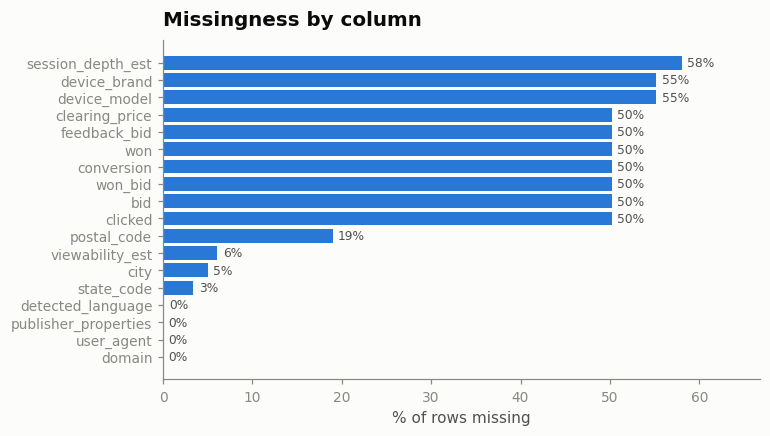

In [5]:
# Missingness bar chart (only columns that actually have gaps)
miss = (df.isna().mean()*100)
miss = miss[miss>0].sort_values()
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(miss.index, miss.values, color=vs.SEQUENTIAL)
for y,v in enumerate(miss.values):
    ax.text(v+0.6, y, f"{v:.0f}%", va="center", fontsize=8, color=vs.INK_SECONDARY)
vs.despine_labels(ax, "Missingness by column", "% of rows missing", None)
ax.set_xlim(0, miss.max()*1.15); ax.grid(False)
save(fig, "q1_missingness.png"); plt.show()

### 1.2 The RTB funnel — where opportunities go

,stage,count,pct_of_requests,pct_of_prev_meaningful
0,Requests (opportunities),"249,232",100.0%,nan%
1,Bidded,"124,152",49.8%,49.8%
2,Won auction,"46,562",18.7%,37.5%
3,Converted (click),"4,368",1.8%,9.4%


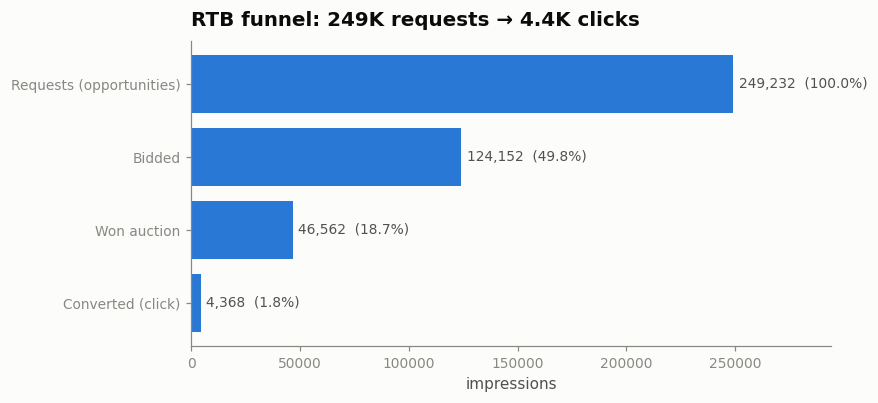

In [6]:
funnel = pf.funnel(df)
display(funnel.style.format({"count":"{:,.0f}","pct_of_requests":"{:.1%}","pct_of_prev_meaningful":"{:.1%}"}))

stages = funnel["stage"].tolist(); counts = funnel["count"].tolist()
fig, ax = plt.subplots(figsize=(7.5,3.6))
bars = ax.barh(range(len(stages)), counts, color=[vs.CATEGORICAL[0]]+[vs.SEQUENTIAL]*3)
ax.set_yticks(range(len(stages))); ax.set_yticklabels(stages); ax.invert_yaxis()
for i,(c,b) in enumerate(zip(counts,bars)):
    pct = c/counts[0]
    ax.text(c+2500, i, f"{c:,}  ({pct:.1%})", va="center", fontsize=9, color=vs.INK_SECONDARY)
vs.despine_labels(ax, "RTB funnel: 249K requests → 4.4K clicks", "impressions", None)
ax.set_xlim(0, counts[0]*1.18); ax.grid(False)
save(fig, "q1_funnel.png"); plt.show()

**Reading the funnel.** We bid on **49.8%** of opportunities, win **37.5%** of
those, and see a click on **9.4% of served (won) impressions**. The 9.4% is the
*true* CTR — clicks can only happen on ads we actually showed. A tempting mistake is
to divide clicks by *all* bids (→ 3.5%); every lost bid has `conversion == 0` by
construction, which would deflate CTR. **CTR is only defined on the won subset**, and
we compute Q2 there.

### 1.3 Prices are heavy-tailed, and auction type splits the world in two

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
bid,124152.0,4.133,20.869,0.06,0.131,0.302,0.74,1.83,4.712,78.662,700.00
feedback_bid,124150.0,4.838,26.679,0.01,0.210,0.500,1.41,3.29,7.120,43.548,1243.75


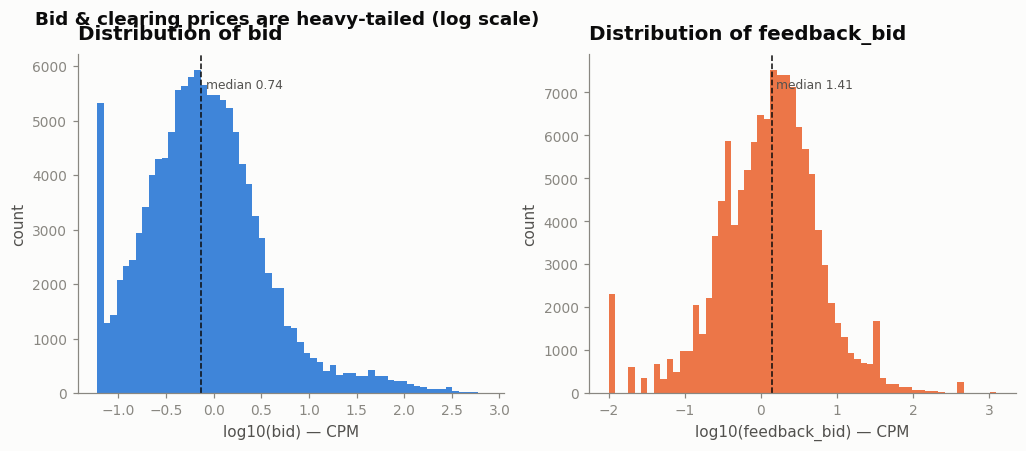

In [7]:
bidded = dl.bidded_frame(df)
display(pf.numeric_summary(bidded, ["bid","feedback_bid"]))

fig, axes = plt.subplots(1,2, figsize=(11,4))
for ax,col,color in zip(axes, ["bid","feedback_bid"], [vs.CATEGORICAL[0], vs.CATEGORICAL[1]]):
    data = bidded[col].dropna()
    data = data[data>0]
    ax.hist(np.log10(data), bins=60, color=color, alpha=0.9)
    ax.set_xlabel(f"log10({col}) — CPM"); ax.grid(False)
    med = np.log10(data.median())
    ax.axvline(med, color=vs.INK, lw=1, ls="--")
    ax.text(med+0.05, ax.get_ylim()[1]*0.9, f"median {data.median():.2f}", fontsize=8, color=vs.INK_SECONDARY)
    vs.despine_labels(ax, f"Distribution of {col}", None, "count")
fig.suptitle("Bid & clearing prices are heavy-tailed (log scale)", x=0.09, ha="left", weight="bold")
save(fig, "q1_price_dist.png"); plt.show()

In [8]:
at = bidded.groupby("auction_type").agg(
    n=("won_bid","size"), share=("won_bid", lambda s: len(s)/len(bidded)),
    win_rate=("won_bid","mean"), median_bid=("bid","median"), median_feedback=("feedback_bid","median"))
display(at.style.format({"n":"{:,.0f}","share":"{:.1%}","win_rate":"{:.1%}","median_bid":"{:.2f}","median_feedback":"{:.2f}"}))

,n,share,win_rate,median_bid,median_feedback
auction_type,,,,,
FIRST_PRICE,"114,871",92.5%,33.2%,0.66,1.31
SECOND_PRICE,"9,281",7.5%,90.4%,12.79,8.64


**The single most important structural fact for bidding.** The two auction
types are almost different markets. **First-price** (92% of our bids) is competitive:
we win only ~33% at a ~1.4 CPM median. **Second-price** is a near-monopoly: we win
~90%, but the clearing prices are an order of magnitude higher. Any pricing or
win-rate logic (Q3) **must stratify by `auction_type`** or it will be nonsense.

### 1.4 Who and where: device & geography

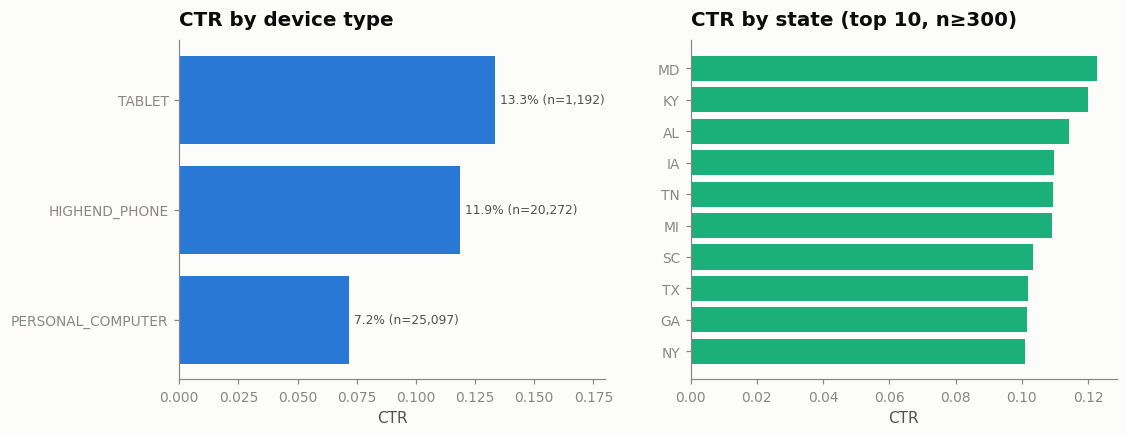

In [9]:
won = dl.won_frame(df)
dev = pf.rate_by_category(won, "device_type", "conversion", min_n=50).rename(columns={"rate":"ctr"})
top_states = pf.rate_by_category(won, "state_code", "conversion", min_n=300).rename(columns={"rate":"ctr"}).head(10)

fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].barh(dev["device_type"], dev["ctr"], color=vs.SEQUENTIAL)
axes[0].invert_yaxis()
for y,(v,n) in enumerate(zip(dev["ctr"],dev["n"])):
    axes[0].text(v+0.002, y, f"{v:.1%} (n={n:,})", va="center", fontsize=8, color=vs.INK_SECONDARY)
vs.despine_labels(axes[0], "CTR by device type", "CTR", None); axes[0].grid(False); axes[0].set_xlim(0, dev["ctr"].max()*1.35)

axes[1].barh(top_states["state_code"], top_states["ctr"], color=vs.CATEGORICAL[2])
axes[1].invert_yaxis()
vs.despine_labels(axes[1], "CTR by state (top 10, n≥300)", "CTR", None); axes[1].grid(False)
save(fig, "q1_device_geo.png"); plt.show()

**Q1 takeaways.**
- One clean day of **249,232** US impressions; **`country` and `screen_orientation`
  are constant** and should be dropped.
- The funnel is **50% bid → 37.5% win → 9.4% CTR** (on won). Missingness is
  *structural* (tied to `bidded` and to desktop device reporting).
- **Prices are heavy-tailed** and **auction type bifurcates the market** — the key
  lever for Q3.
- Clicks concentrate on **mobile/tablet** and vary by **geography** — foreshadowing
  Q2.


---
## Q2 — Most promising features for predicting CTR

The ask is an **analysis**: produce a *justified* feature set, not a model. Two
principles shape the whole answer.

**(a) Guard against leakage.** We would score CTR *before* deciding whether/what to
bid. So any field produced *by or after* the auction is off-limits as a predictor:
`bid`, `won_bid`, `feedback_bid`, and of course `conversion` itself. Including them
would inflate offline metrics and be unusable in production.

**(b) Condition on the served set.** CTR only exists where `won_bid == 1`; we rank
features on that subset.

**How we rank.** Clicks are rare (~9%), so we avoid raw correlation. For
**categorical** features we use **Information Value (IV)** built from Weight of
Evidence — the industry standard for ranking predictors of a rare binary event. For
**numeric** features we use **mutual information**, which captures non-linear
association. Both are model-agnostic screening measures.


In [10]:
print("Excluded as leakage:", sorted(cf.LEAKAGE_COLUMNS))
print("Excluded as raw identifiers (high-cardinality / obfuscated):", sorted(cf.IDENTIFIER_COLUMNS))

cat_candidates = ["device_brand","device_type","detected_language","is_wifi",
                  "auction_type","state_code","city","hour","viewability_missing","session_depth_missing"]
num_candidates = ["viewability_est","session_depth_est","cookie_age_seconds"]
print("\nCategorical candidates:", cat_candidates)
print("Numeric candidates:", num_candidates)

Excluded as leakage: ['bid', 'clearing_price', 'clicked', 'conversion', 'feedback_bid', 'won', 'won_bid']
Excluded as raw identifiers (high-cardinality / obfuscated): ['ad_slot', 'domain', 'publisher_properties', 'time', 'url', 'user_agent', 'user_id']

Categorical candidates: ['device_brand', 'device_type', 'detected_language', 'is_wifi', 'auction_type', 'state_code', 'city', 'hour', 'viewability_missing', 'session_depth_missing']
Numeric candidates: ['viewability_est', 'session_depth_est', 'cookie_age_seconds']


### 2.1 Categorical feature strength — Information Value

,feature,information_value,n_unique,strength
0,device_brand,0.1059,53,medium
1,device_type,0.0797,4,weak
2,viewability_missing,0.0464,2,weak
3,city,0.0326,5195,weak
4,state_code,0.0260,51,weak
5,auction_type,0.0223,2,weak
6,is_wifi,0.0166,2,useless
7,hour,0.0143,24,useless
8,detected_language,0.0036,18,useless
9,session_depth_missing,0.0005,2,useless


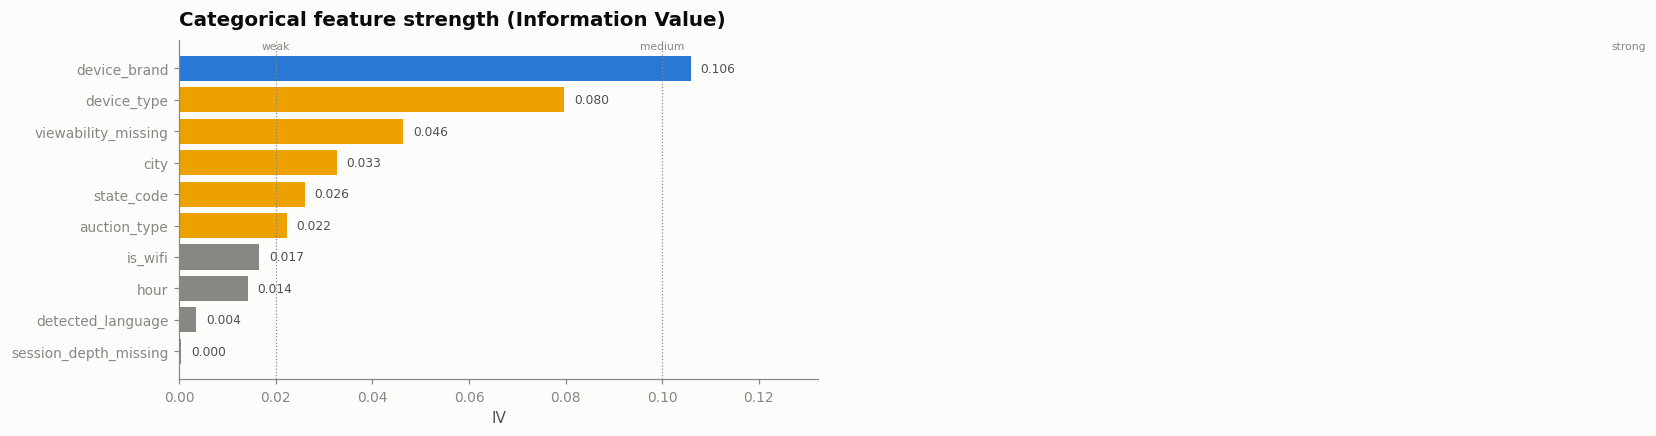

In [11]:
iv = cf.rank_categorical_iv(won, cat_candidates)
display(iv.style.format({"information_value":"{:.4f}"}))

fig, ax = plt.subplots(figsize=(7.5,4))
colors = {"strong":vs.STATUS["good"], "medium":vs.CATEGORICAL[0], "weak":vs.CATEGORICAL[3], "useless":vs.INK_MUTED}
bar_colors = [colors[str(s)] for s in iv["strength"]]
ax.barh(iv["feature"], iv["information_value"], color=bar_colors)
ax.invert_yaxis()
for th,lab in [(0.02,"weak"),(0.1,"medium"),(0.3,"strong")]:
    ax.axvline(th, color=vs.INK_MUTED, lw=0.8, ls=":")
    ax.text(th, -0.6, lab, fontsize=7, color=vs.INK_MUTED, ha="center")
for y,v in enumerate(iv["information_value"]):
    ax.text(v+0.002, y, f"{v:.3f}", va="center", fontsize=8, color=vs.INK_SECONDARY)
vs.despine_labels(ax, "Categorical feature strength (Information Value)", "IV", None)
ax.grid(False); ax.set_xlim(0, iv["information_value"].max()*1.25)
save(fig, "q2_iv_ranking.png"); plt.show()

### 2.2 Numeric feature strength — Mutual Information

,feature,mutual_info
0,session_depth_est,0.01785
1,viewability_est,0.01102
2,cookie_age_seconds,0.00315


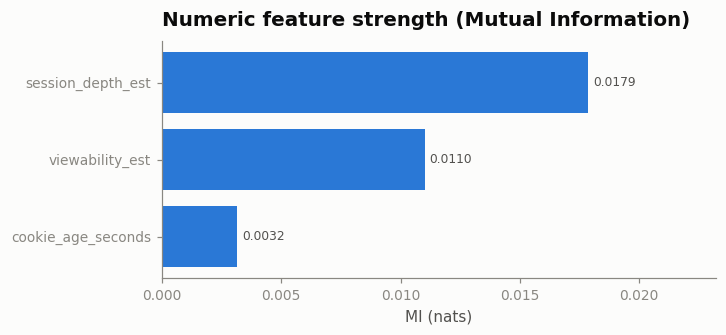

In [12]:
mi = cf.rank_numeric_mi(won, num_candidates)
display(mi.style.format({"mutual_info":"{:.5f}"}))

fig, ax = plt.subplots(figsize=(6.5,2.8))
ax.barh(mi["feature"], mi["mutual_info"], color=vs.SEQUENTIAL); ax.invert_yaxis()
for y,v in enumerate(mi["mutual_info"]):
    ax.text(v+2e-4, y, f"{v:.4f}", va="center", fontsize=8, color=vs.INK_SECONDARY)
vs.despine_labels(ax, "Numeric feature strength (Mutual Information)", "MI (nats)", None)
ax.grid(False); ax.set_xlim(0, mi["mutual_info"].max()*1.3)
save(fig, "q2_mi_ranking.png"); plt.show()

### 2.3 What the top features actually look like

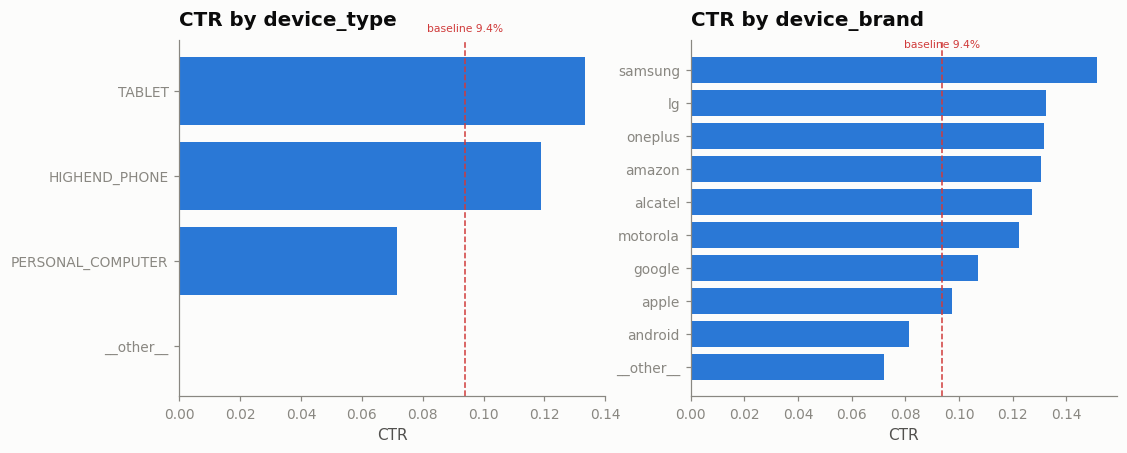

In [13]:
# WoE detail: CTR across the levels of the two strongest categoricals.
fig, axes = plt.subplots(1,2, figsize=(11,4.2))
for ax, feat, k in zip(axes, ["device_type","device_brand"], [4, 12]):
    tab,_ = cf.woe_iv(won, feat)
    tab = tab.sort_values("ctr", ascending=False).head(k)
    ax.barh(tab.index.astype(str), tab["ctr"], color=vs.SEQUENTIAL); ax.invert_yaxis()
    ax.axvline(won["conversion"].mean(), color=vs.STATUS["critical"], lw=1, ls="--")
    ax.text(won["conversion"].mean(), -0.7, f"baseline {won['conversion'].mean():.1%}",
            fontsize=7, color=vs.STATUS["critical"], ha="center")
    vs.despine_labels(ax, f"CTR by {feat}", "CTR", None); ax.grid(False)
save(fig, "q2_woe_detail.png"); plt.show()

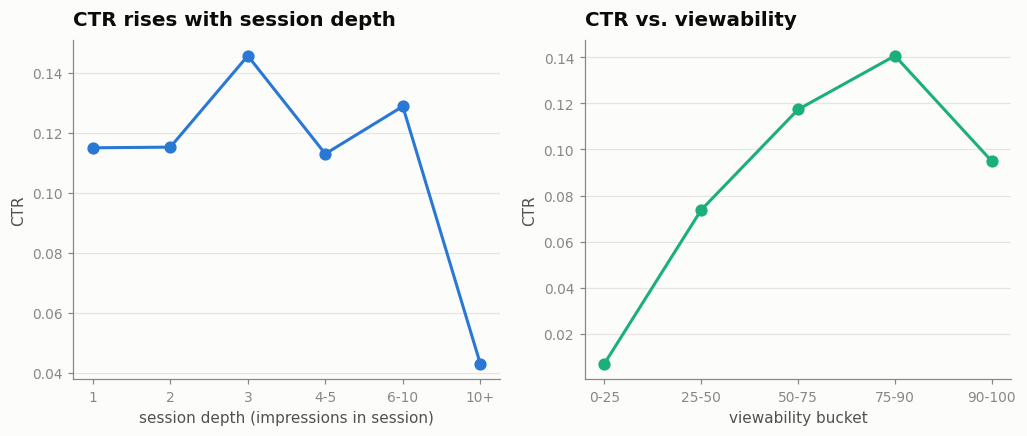

In [14]:
# Sessions and viewability: does engagement/quality move CTR?
fig, axes = plt.subplots(1,2, figsize=(11,4))
# session depth bucketed
w = won.copy()
w["sd_bin"] = pd.cut(w["session_depth_est"], [0,1,2,3,5,10,1e9],
                     labels=["1","2","3","4-5","6-10","10+"])
sd = w.groupby("sd_bin")["conversion"].agg(["mean","size"]).dropna()
axes[0].plot(sd.index.astype(str), sd["mean"], marker="o", color=vs.CATEGORICAL[0], lw=2, ms=7)
vs.despine_labels(axes[0], "CTR rises with session depth", "session depth (impressions in session)", "CTR")
# viewability bucketed
w["vb_bin"] = pd.cut(w["viewability_est"], [-1,25,50,75,90,100], labels=["0-25","25-50","50-75","75-90","90-100"])
vb = w.groupby("vb_bin")["conversion"].agg(["mean","size"]).dropna()
axes[1].plot(vb.index.astype(str), vb["mean"], marker="o", color=vs.CATEGORICAL[2], lw=2, ms=7)
vs.despine_labels(axes[1], "CTR vs. viewability", "viewability bucket", "CTR")
save(fig, "q2_signal_trends.png"); plt.show()

### 2.4 Recommended feature set (with justification)

Ranked by measured association on the served set, guarding against leakage:

| Feature | Type | Signal | Why it makes the cut |
|---|---|---|---|
| **`device_brand`** | categorical | IV ≈ 0.11 (**medium**) | Strongest single predictor; brand proxies platform, price tier, ad rendering. |
| **`device_type`** | categorical | IV ≈ 0.08 | Mobile/tablet click far above desktop; robust, low-cardinality. |
| **`session_depth`** | numeric | top MI | Monotonic — deeper sessions click more (engagement proxy). Keep the `-1` missing flag. |
| **`viewability`** | numeric | 2nd MI | Directly the odds an ad is *seen*; keep the `-1` missing flag. |
| **`state_code` / geo** | categorical | IV ≈ 0.03 | Weak but stable and cheap; useful as a target-encoded aggregate. |
| **`auction_type`** | categorical | IV ≈ 0.02 | Weak for CTR but essential context; nearly free. |
| **`cookie_age_seconds`** | numeric | low MI | Recency/identity proxy; better bucketed (new vs. established cookie). |

**Deliberately excluded**
- **Leakage:** `bid`, `won_bid`, `feedback_bid` — unknown pre-bid.
- **Constant:** `country`, `screen_orientation` — zero variance.
- **Near-constant / noisy:** `detected_language` (98% `en`), `is_wifi`, raw `hour`.
- **Raw identifiers:** `user_id`, `url`, `domain`, `ad_slot`, `user_agent` — not usable
  as-is, but **high-value as target-encoded / historical-CTR aggregates** (e.g. a
  smoothed historical CTR per `ad_slot`), which is typically the single biggest CTR
  feature in production RTB and the natural next step.

**Bottom line:** device identity + engagement/quality (session depth, viewability) +
light geo context is the promising, leakage-safe core; the biggest future lift comes
from historical CTR aggregates over the identifier columns.


---
## Q3 — Guessing the pre-bid CPM to win X% of the time (per `url × ad_slot`)

**Restated.** Build `bid(url, ad_slot, X)` → the CPM that wins the auction X% of the
time, computable *before* we bid.

**The key idea.** To win, our bid must exceed the market's **clearing price** for
that slot. If `F` is the CDF of the clearing price, then

$$P(\text{win} \mid \text{bid}=b) = P(b > \text{clearing price}) = F(b),$$

so the bid that wins a fraction \(X\) of the time is simply the **X-th quantile of the
clearing-price distribution** for that `url × ad_slot`:

$$\text{bid}(X) = F^{-1}(X) = Q_X(\text{clearing price}).$$

Q3 therefore reduces to **estimating clearing-price quantiles per slot.**

**Where does the clearing price come from?** From `feedback_bid`, which is exactly
the price that *decided* the auction under both auction types (the winner's bid when
we lost; the runner-up when we won a first-price auction). It is our best
single-number estimate of "what it took to win this slot," so we treat
`clearing_price ≈ feedback_bid` (see `src/data_loading.add_derived`).


### 3.1 The real obstacle: sparsity

Unique (url, ad_slot) pairs: 13,817
Median observations per pair: 2
  pairs with ≥  1 obs: 13,817  (100.0%)
  pairs with ≥  5 obs:  4,047  (29.3%)
  pairs with ≥ 20 obs:  1,075  (7.8%)
  pairs with ≥ 50 obs:    359  (2.6%)
  pairs with ≥100 obs:    168  (1.2%)


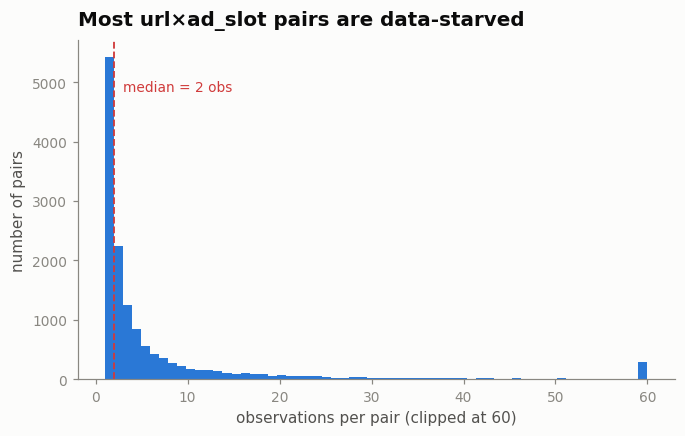

In [15]:
pair_n = bidded.dropna(subset=["clearing_price"]).groupby(["url","ad_slot"]).size()
print(f"Unique (url, ad_slot) pairs: {pair_n.size:,}")
print(f"Median observations per pair: {pair_n.median():.0f}")
for th in [1,5,20,50,100]:
    print(f"  pairs with ≥{th:>3} obs: {(pair_n>=th).sum():>6,}  ({(pair_n>=th).mean():.1%})")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.clip(pair_n.values,0,60), bins=60, color=vs.SEQUENTIAL)
ax.axvline(pair_n.median(), color=vs.STATUS["critical"], lw=1.2, ls="--")
ax.text(pair_n.median()+1, ax.get_ylim()[1]*0.85, f"median = {pair_n.median():.0f} obs",
        color=vs.STATUS["critical"], fontsize=9)
vs.despine_labels(ax, "Most url×ad_slot pairs are data-starved", "observations per pair (clipped at 60)", "number of pairs")
ax.grid(False); save(fig, "q3_sparsity.png"); plt.show()

A raw per-pair empirical quantile is hopeless when the median pair has ~2
observations. The fix is **hierarchical partial pooling (empirical-Bayes shrinkage)**:
estimate the quantile at the pair level where data is rich, and otherwise **borrow
strength** from progressively broader levels — `url → ad_slot → domain → (auction
stratum) → global` — weighting each level by its support. Pooling never crosses the
`auction_type` boundary, because §1.3 showed those are different price regimes.
`src/bid_landscape.HierarchicalQuantileModel` implements this.

### 3.2 Fit the model and read off bid curves

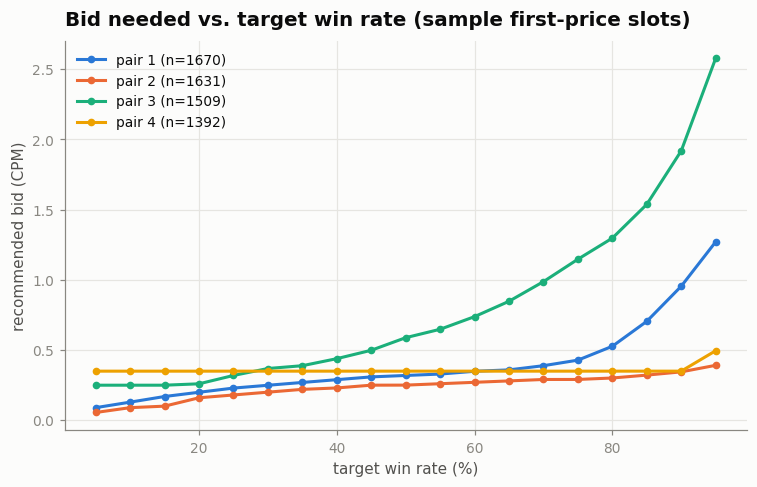

In [16]:
model = bl.HierarchicalQuantileModel(levels=["url","ad_slot","domain"], pseudo_count=30).fit(bidded)

# Bid curves for a few well-populated first-price pairs.
fp = bidded[(bidded.auction_type=="FIRST_PRICE") & bidded.clearing_price.notna()]
top_pairs = fp.groupby(["url","ad_slot"]).size().sort_values(ascending=False).head(4).index
targets = np.linspace(0.05, 0.95, 19)

fig, ax = plt.subplots(figsize=(8,4.6))
for i,(u,s) in enumerate(top_pairs):
    row = fp[(fp.url==u)&(fp.ad_slot==s)].iloc[0]
    curve = [model.bid_for_winrate(row, x) for x in targets]
    ax.plot(targets*100, curve, marker="o", ms=4, lw=2, color=vs.CATEGORICAL[i],
            label=f"pair {i+1} (n={((fp.url==u)&(fp.ad_slot==s)).sum()})")
vs.despine_labels(ax, "Bid needed vs. target win rate (sample first-price slots)",
                  "target win rate (%)", "recommended bid (CPM)")
ax.legend(); ax.grid(True); save(fig, "q3_bid_curves.png"); plt.show()

Each curve is a slot's **supply curve of winning**: buying a higher win rate
costs a higher CPM, and the curve's shape (steepness) reflects how contested that
slot is. This is directly actionable — pick a target win rate, read off the bid.

### 3.3 Does it work? A calibration back-test

,target,median_realised,mean_realised,n_pairs
0,20%,20.0%,22.1%,359
1,50%,50.5%,51.5%,359
2,80%,80.1%,80.8%,359


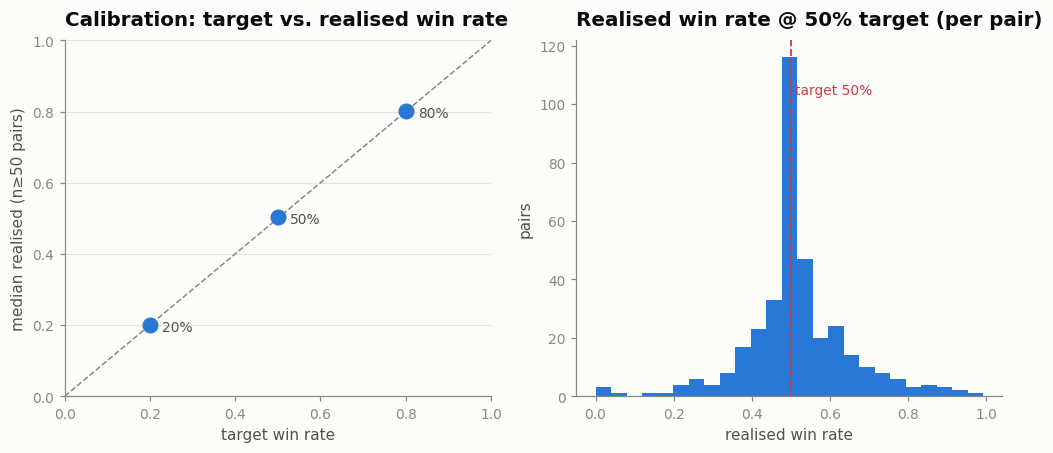

In [17]:
# For well-populated pairs, bid the model's price and measure the realised win rate.
rows = []
for x in [0.2, 0.5, 0.8]:
    cal = bl.calibration_by_pair(bidded, model, x, min_n=50)
    rows.append((x, cal["realised_win_rate"].median(), cal["realised_win_rate"].mean(), len(cal)))
caldf = pd.DataFrame(rows, columns=["target","median_realised","mean_realised","n_pairs"])
display(caldf.style.format({"target":"{:.0%}","median_realised":"{:.1%}","mean_realised":"{:.1%}"}))

cal50 = bl.calibration_by_pair(bidded, model, 0.5, min_n=50)
fig, axes = plt.subplots(1,2, figsize=(11,4.2))
# (a) target vs realised
axes[0].plot([0,1],[0,1], color=vs.INK_MUTED, ls="--", lw=1)
axes[0].scatter(caldf["target"], caldf["median_realised"], s=90, color=vs.CATEGORICAL[0], zorder=3)
for _,r in caldf.iterrows():
    axes[0].annotate(f"{r.median_realised:.0%}", (r.target, r.median_realised),
                     textcoords="offset points", xytext=(8,-4), fontsize=9, color=vs.INK_SECONDARY)
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
vs.despine_labels(axes[0], "Calibration: target vs. realised win rate", "target win rate", "median realised (n≥50 pairs)")
# (b) distribution of realised win rates at 50% target
axes[1].hist(cal50["realised_win_rate"], bins=25, color=vs.SEQUENTIAL)
axes[1].axvline(0.5, color=vs.STATUS["critical"], lw=1.2, ls="--")
axes[1].text(0.5+0.01, axes[1].get_ylim()[1]*0.85, "target 50%", color=vs.STATUS["critical"], fontsize=9)
vs.despine_labels(axes[1], "Realised win rate @ 50% target (per pair)", "realised win rate", "pairs")
axes[1].grid(False); save(fig, "q3_calibration.png"); plt.show()

**The model is well-calibrated:** across well-populated pairs, bidding the
predicted price for a 50% target wins almost exactly 50% of the time, and the 20% /
80% targets land on their marks too. The shrinkage keeps sparse pairs sane while
letting rich pairs speak for themselves.

### 3.4 How I'd productionise it (and a scalable alternative)

**The estimator above is the answer**, and it is deployable: precompute, per auction
stratum and per level (`url`, `ad_slot`, `domain`), a small grid of clearing-price
quantiles; at request time look up the finest level available and blend by support.
It is O(1) to serve, needs no online training, and degrades gracefully to broader
priors for cold slots.

**Where it needs care / how to extend:**
- **Censoring.** When we lose we only know the clearing price was *above*
  `feedback_bid` for our own bid, but `feedback_bid` on losses is the *winner's* bid —
  a fair market-price read. For fully rigorous treatment, model the win indicator vs.
  our bid with **survival analysis (Kaplan–Meier / Cox)** to handle censoring explicitly.
- **Features beyond IDs.** To generalise to unseen slots, replace the ID hierarchy
  with a **quantile-regression model** (e.g. gradient-boosted trees with a pinball
  loss, or `sklearn`'s `GradientBoostingRegressor(loss="quantile", alpha=X)`), using
  `hour`, `device_type`, `viewability`, `domain`-embeddings, etc. This trades the
  interpretability of the hierarchy for coverage on cold-start slots.
- **Recency.** Clearing prices drift; in production, weight recent observations more
  (exponential decay) and refresh the quantile grid on a schedule.


---
## Summary

| Q | Answer in one line |
|---|---|
| **1** | 249K one-day US impressions; funnel = 50% bid → 37.5% win → **9.4% CTR** (on won); prices heavy-tailed; **auction type splits the market**; `country`/`screen_orientation` are dead. |
| **2** | Leakage-safe, data-ranked core: **`device_brand`, `device_type`, `session_depth`, `viewability`** (+ light geo/auction context); biggest future lift = **historical-CTR aggregates** over the ID columns. |
| **3** | Win-rate ⇔ clearing-price CDF ⇒ **bid(X) = X-th quantile of clearing price** per slot, estimated with **hierarchical shrinkage** to beat sparsity; **calibrates to target within ~1pt**; extend with survival analysis / quantile regression. |

*Reproducible: logic in `src/`, figures in `reports/figures/`, notebook regenerated by `build_notebook.py`.*
